In [69]:
import pandas as pd
import numpy as np

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import *

import matplotlib.pyplot as plt
import seaborn as sns
import glob

In [67]:
df = pd.read_csv(r"C:\Users\shaik\OneDrive\Desktop\Pyton Class\Data set\bank fraud\Variant III.csv")

In [70]:
df.head()

,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,payment_type,zip_count_4w,...,foreign_request,source,session_length_in_minutes,device_os,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month,x1,x2
0,0,0.5,0.489311,24,20,50,0.019819,-0.857899,AC,1842,...,0,INTERNET,1.873109,other,0,1,0,0,-0.351078,-0.429230
1,0,0.9,0.535394,-1,82,40,0.007959,-1.560356,AB,1241,...,0,INTERNET,20.170591,linux,1,1,0,0,-0.424817,0.394155
2,0,0.5,0.188964,-1,73,60,0.027117,-0.897317,AC,1095,...,0,INTERNET,1.722109,other,1,1,0,0,-1.974833,0.332406
3,0,0.4,0.391397,29,5,20,0.021103,-0.473215,AB,888,...,0,INTERNET,2.152433,linux,1,1,0,0,-0.579442,0.427254
4,0,0.1,0.592711,-1,267,40,0.039380,16.213862,AA,599,...,0,INTERNET,14.204698,other,0,1,0,0,1.915776,1.363967


In [71]:
df.shape

(1000000, 34)

In [72]:
df.source.unique()

array(['INTERNET', 'TELEAPP'], dtype=object)

In [11]:
sns.scatterplot?

In [12]:
sns.barplot?

<AxesSubplot: xlabel='payment_type', ylabel='income'>

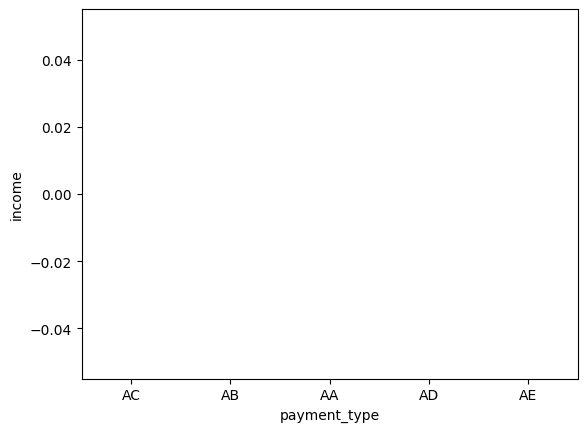

In [29]:
sns.barplot(data=df, y=df.income.value_counts(), x= 'payment_type')

In [21]:
df.fraud_bool.value_counts()

0    988970
1     11030
Name: fraud_bool, dtype: int64

In [22]:
y=df.fraud_bool.value_counts()

In [23]:
y

0    988970
1     11030
Name: fraud_bool, dtype: int64

<AxesSubplot: xlabel='payment_type', ylabel='fraud_bool'>

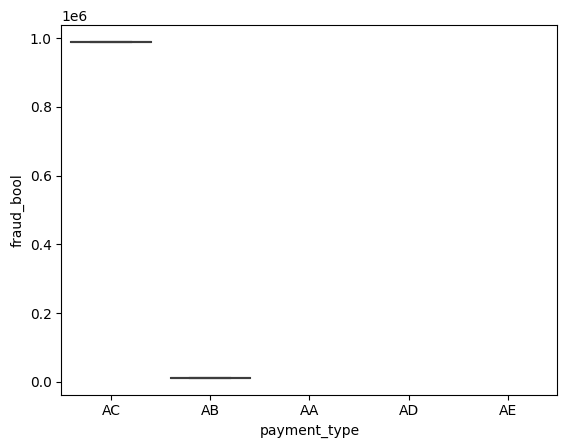

In [27]:
sns.boxplot(y=df.fraud_bool.value_counts(),x='payment_type',data=df)

<AxesSubplot: xlabel='days_since_request', ylabel='name_email_similarity'>

C:\Users\shaik\anaconda3\Lib\site-packages\IPython\core\events.py:89: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
C:\Users\shaik\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


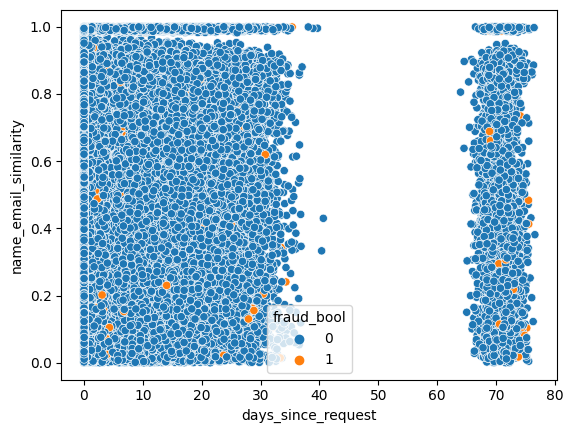

In [39]:
sns.scatterplot(y='name_email_similarity',x='days_since_request',data=df, hue='fraud_bool')

In [41]:
sns.heatmap(data=df, x= 'payment_type',y= 'fraud_bool')

ValueError: could not convert string to float: 'AC'

In [50]:
df.isnull().sum()

fraud_bool                          0
income                              0
name_email_similarity               0
prev_address_months_count           0
current_address_months_count        0
customer_age                        0
days_since_request                  0
intended_balcon_amount              0
payment_type                        0
zip_count_4w                        0
velocity_6h                         0
velocity_24h                        0
velocity_4w                         0
bank_branch_count_8w                0
date_of_birth_distinct_emails_4w    0
employment_status                   0
credit_risk_score                   0
email_is_free                       0
housing_status                      0
phone_home_valid                    0
phone_mobile_valid                  0
bank_months_count                   0
has_other_cards                     0
proposed_credit_limit               0
foreign_request                     0
source                              0
session_leng

In [56]:
df2 = pd.get_dummies(df)

In [57]:
df2


,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,zip_count_4w,velocity_6h,...,housing_status_BE,housing_status_BF,housing_status_BG,source_INTERNET,source_TELEAPP,device_os_linux,device_os_macintosh,device_os_other,device_os_windows,device_os_x11
0,0,0.5,0.489311,24,20,50,0.019819,-0.857899,1842,1035.647957,...,0,0,0,1,0,0,0,1,0,0
1,0,0.9,0.535394,-1,82,40,0.007959,-1.560356,1241,6594.341545,...,0,0,0,1,0,1,0,0,0,0
2,0,0.5,0.188964,-1,73,60,0.027117,-0.897317,1095,9466.532445,...,1,0,0,1,0,0,0,1,0,0
3,0,0.4,0.391397,29,5,20,0.021103,-0.473215,888,9607.127166,...,1,0,0,1,0,1,0,0,0,0
4,0,0.1,0.592711,-1,267,40,0.039380,16.213862,599,7747.526433,...,0,0,0,1,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,0,0.2,0.895449,-1,370,30,0.010500,-1.158884,1043,1732.238724,...,0,0,0,1,0,0,0,1,0,0
999996,0,0.6,0.493250,86,6,60,0.023927,-1.208242,632,7026.986885,...,0,0,0,1,0,1,0,0,0,0
999997,0,0.5,0.702840,-1,55,30,0.000151,-0.823842,550,3700.037912,...,0,0,0,1,0,1,0,0,0,0
999998,0,0.8,0.895087,102,9,40,0.008903,-1.247509,821,3312.542249,...,0,0,0,1,0,0,0,1,0,0


In [62]:
x = df2.drop('fraud_bool',axis=1)
y = df2.fraud_bool

In [63]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2)

In [64]:
model = RandomForestRegressor(max_depth = 10,n_estimators=200)
model.fit(x_train,y_train)

KeyboardInterrupt: 

In [ ]:
trainPred = model.predict(x_train)
testPred = model.predict(x_test)